# Exp2 - Greedy contextual de inyección de fuentes: resumen y evidencia visual

**Alcance:** consolidar la campaña greedy `contextual_greedy/20260505T012242Z` (32 ramas) donde se evalúa si
añadir bloques de fuentes alternativas (`derivatives_futures`, `microstructure`, `onchain`, `sentiment`, `attention`)
sobre el subconjunto `core_only` mejora el Sharpe agregado. Se quiere auditar la **decisión final del greedy**
(`winner_subset`, `winner_depth`, `winner_verdict`), no la mejor configuración bajo búsqueda exhaustiva.

**Insumo principal en disco:**
- `reports/validation/experiments/contextual_greedy/20260505T012242Z/greedy_summary.json`: ganadores por rama (`load_exp2_winners`), nodos del selector greedy embebidos (sec. 2.1 y 4 via `build_exp2_*`) y pareado staged/monolithic (sec. 5 via `build_exp2_injection_staged_vs_monolithic_pivot` en `phase_summaries`).

**Consolidación:** la auditoría ejecutiva del árbol (veredictos por nodo hijo, valor añadido por bloque y contraste staged/monolithic) vive en este notebook. No se mantiene un notebook separado de evidencia intermedia: todas las tablas se calculan en ejecución desde `greedy_summary.json`, no desde CSVs pre-generados en `evidence/`.

**Estructura del notebook:**
| Sección | Contenido |
|---------|-----------|
| **1** | Completitud de la campaña y reparto por familia / método / símbolo |
| **1.1** | Parámetros del greedy y umbrales de decisión (`alpha`, `beta`, `gamma`, `source_order`) |
| **2** | Decisión del greedy: `winner_subset`, `winner_depth`, `winner_verdict` |
| **2.1** | Veredictos sobre los nodos hijo evaluados (auditoría del árbol) |
| **3** | Distribución del Sharpe agregado del nodo ganador |
| **3.1** | Heatmap 2D: Sharpe ganador por celda (`símbolo/método`) × (`familia/inyección`) |
| **4** | Valor añadido por bloque de fuentes alternativas |
| **5** | Estrategia de inyección: staged vs. monolithic |
| **6** | Tiempos de ejecución y coste computacional |
| **7** | DSR del campeón greedy (N acumulado Exp1 + Exp2) |
| **8** | Conclusiones |

**Productos:** tablas CSV y figuras PNG bajo `reports/figures/exp_synthesis/exp2/` (lista exhaustiva en la sección 8).

In [12]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.options.display.max_columns = 60
pd.options.display.max_rows = 200
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

COLUMNAS_ES = {
    'symbol': 'simbolo',
    'method': 'metodo',
    'family': 'familia',
    'injection_strategy': 'estrategia_inyeccion',
    'branch_started_utc': 'inicio_rama_utc',
    'branch_finished_utc': 'fin_rama_utc',
    'winner_subset': 'subset_ganador',
    'winner_depth': 'profundidad_ganador',
    'winner_aggregate_sharpe': 'sharpe_agregado_ganador',
    'winner_verdict': 'veredicto_ganador',
    'winner_study_id': 'id_estudio_ganador',
    'branch_runtime_hours': 'horas_ejecucion_rama',
    'active_blocks_id': 'bloque_alternativo',
    'n_nodes': 'n_nodos',
    'median_delta_sharpe_median': 'mediana_delta_sharpe',
    'median_delta_sharpe_mean': 'media_delta_sharpe',
    'wilcoxon_p_median': 'p_wilcoxon',
    'aggregate_sharpe_median': 'mediana_sharpe_agregado',
    'staged': 'sharpe_por_etapas',
    'monolithic': 'sharpe_monolitico',
    'sharpe_staged': 'sharpe_por_etapas',
    'sharpe_monolithic': 'sharpe_monolitico',
    'diff_monolithic_minus_staged': 'diferencia_monolitico_menos_staged',
    'diferencia_monolithic_menos_staged': 'diferencia_monolitico_menos_staged',
}


def _nombre_columna_es(nombre: str) -> str:
    return COLUMNAS_ES.get(nombre, nombre)


def a_es(frame: pd.DataFrame | pd.Series) -> pd.DataFrame:
    if isinstance(frame, pd.Series):
        frame = frame.to_frame(name=frame.name)
    vista = frame.copy()
    vista.columns = [_nombre_columna_es(str(col)) for col in vista.columns]
    if vista.index.name:
        vista.index.name = _nombre_columna_es(str(vista.index.name))
    if isinstance(vista.index, pd.MultiIndex):
        vista.index = vista.index.set_names([
            _nombre_columna_es(str(name)) if name is not None else name
            for name in vista.index.names
        ])
    return vista


def display_es(frame: pd.DataFrame | pd.Series) -> None:
    display(a_es(frame))


def locate_repo_root(start: Path | None = None) -> Path:
    root = (start or Path.cwd()).resolve()
    while root != root.parent and not (root / 'src').exists():
        root = root.parent
    if not (root / 'src').exists():
        raise FileNotFoundError('No se encontró la raíz del repo (carpeta src/).')
    return root


ROOT = locate_repo_root()
EVIDENCE_DIR = ROOT / 'evidence_utils'
if str(EVIDENCE_DIR) not in sys.path:
    sys.path.insert(0, str(EVIDENCE_DIR))

from phase_summaries import (
    EXP1_STAMP_DEFAULT,
    EXP2_BRANCH_STAMP_DEFAULT,
    build_exp2_greedy_nodes_long,
    build_exp2_injection_staged_vs_monolithic_pivot,
    build_exp2_node_verdict_counts,
    build_exp2_source_acceptance,
    load_exp2_campaign_metadata,
    load_exp2_source_value_added,
    load_exp2_winners,
)

REPORT_ROOT = ROOT / 'reports' / 'validation' / 'experiments'
FIG_DIR = ROOT / 'reports' / 'figures' / 'exp_synthesis' / 'exp2'
FIG_DIR.mkdir(parents=True, exist_ok=True)

BRANCH_STAMP = EXP2_BRANCH_STAMP_DEFAULT

## 1. Completitud de la campaña y reparto por familia/método

Verificación de que las 32 ramas planificadas fueron evaluadas y conteo por dimensiones canónicas
(familia, símbolo, método de etiquetado, estrategia de inyección).

In [13]:
winners = load_exp2_winners(REPORT_ROOT, branch_stamp=BRANCH_STAMP)
a_es(winners).to_csv(FIG_DIR / 'exp2_winners_raw.csv', index=False)

completeness = {
    'n_ramas': int(len(winners)),
    'n_estudios_unicos': int(winners['winner_study_id'].nunique()),
    'n_simbolos': int(winners['symbol'].nunique()),
    'n_metodos': int(winners['method'].nunique()),
    'n_familias': int(winners['family'].nunique()),
    'n_ganadores_core_only': int((winners['winner_subset'] == 'core_only').sum()),
    'n_ganadores_subset_alt': int((winners['winner_subset'] != 'core_only').sum()),
}
print('Completitud de campaña')
display_es(pd.DataFrame([completeness]).T.rename(columns={0: 'valor'}))

by_family = winners['family'].value_counts().sort_index().to_frame('n_ramas')
by_method = winners['method'].value_counts().sort_index().to_frame('n_ramas')
by_symbol = winners['symbol'].value_counts().sort_index().to_frame('n_ramas')
a_es(by_family).to_csv(FIG_DIR / 'exp2_branches_by_family.csv')
a_es(by_method).to_csv(FIG_DIR / 'exp2_branches_by_method.csv')
a_es(by_symbol).to_csv(FIG_DIR / 'exp2_branches_by_symbol.csv')
print('Ramas por familia/método/símbolo')
display_es(by_family.T)
display_es(by_method.T)
display_es(by_symbol.T)

Completitud de campaña


,valor
n_ramas,32
n_estudios_unicos,32
n_simbolos,5
n_metodos,3
n_familias,4
n_ganadores_core_only,31
n_ganadores_subset_alt,1


Ramas por familia/método/símbolo


,lstm,residual_hybrid,voting,xgboost
n_ramas,1,20,4,7


,fixed_horizon,trend_scanning,triple_barrier
n_ramas,11,10,11


,BNBUSDT,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT
n_ramas,6,4,7,6,9


## 1.1 Parámetros del greedy y umbrales de decisión

Los veredictos `root`, `beta` y `gamma` que se analizan a partir de la sección 2 no son
etiquetas arbitrarias: son la salida de un test estadístico que aplica el driver greedy
sobre los deltas de Sharpe pareados por fold de cada candidato frente a su nodo padre.
Sin estos umbrales no es posible interpretar por qué la campaña termina mayoritariamente
en `core_only`.

- `wilcoxon_alpha` -> nivel de significación del test pareado de Wilcoxon entre nodo
  candidato y nodo padre.
- `delta_sharpe_beta_upper` -> mínima mediana de delta de Sharpe pareado para aceptar
  como `beta` (mejora positiva).
- `delta_sharpe_gamma_lower` -> mínima mediana de delta de Sharpe pareado para aceptar
  como `gamma` (mejora conservadora bajo Wilcoxon no concluyente).
- `max_depth` -> profundidad máxima del árbol greedy.
- `inner_hp_budget` -> presupuesto de hiperparámetros por nodo evaluado.
- `source_order` -> orden de las fuentes contextuales candidatas que el driver intenta
  añadir sobre `core_only`.

In [14]:
metadata = load_exp2_campaign_metadata(REPORT_ROOT, branch_stamp=BRANCH_STAMP)

NOMBRE_PARAM_ES = {
    'branch_stamp': 'sello_rama',
    'n_branches': 'n_ramas_planificadas',
    'max_depth': 'profundidad_maxima',
    'inner_hp_budget': 'presupuesto_hp_interno',
    'wilcoxon_alpha': 'alpha_wilcoxon',
    'delta_sharpe_beta_upper': 'umbral_delta_sharpe_beta',
    'delta_sharpe_gamma_lower': 'umbral_delta_sharpe_gamma',
    'source_order': 'orden_fuentes_contextuales',
}

filas_thresholds = []
for clave_en, clave_es in NOMBRE_PARAM_ES.items():
    valor = metadata.get(clave_en)
    if isinstance(valor, list):
        valor = ', '.join(map(str, valor))
    filas_thresholds.append({'parametro': clave_es, 'valor': valor})
thresholds_df = pd.DataFrame(filas_thresholds)
thresholds_df.to_csv(FIG_DIR / 'exp2_greedy_thresholds.csv', index=False)
print('Parámetros del greedy y umbrales de decisión')
display(thresholds_df)

Parámetros del greedy y umbrales de decisión


,parametro,valor
0,sello_rama,20260505T012242Z
1,n_ramas_planificadas,32
2,profundidad_maxima,3
3,presupuesto_hp_interno,None
4,alpha_wilcoxon,0.1
5,umbral_delta_sharpe_beta,0.05
6,umbral_delta_sharpe_gamma,0.05
7,orden_fuentes_contextuales,"derivatives_futures, microstructure, onchain, ..."


## 2. Decisión del greedy: subset ganador, profundidad y veredicto

Estas tres dimensiones resumen la pregunta central del Exp2: **¿Cómo queda activado por
rama y con qué veredicto?**

- `winner_subset` -> bloque ganador (`core_only` significa que el greedy no expandió).
- `winner_depth` -> profundidad alcanzada (0 = nodo raíz core).
- `winner_verdict` -> tipo de aceptación (`root` = raíz, `beta` = expansión por mejora positiva, `gamma` = expansión conservadora).

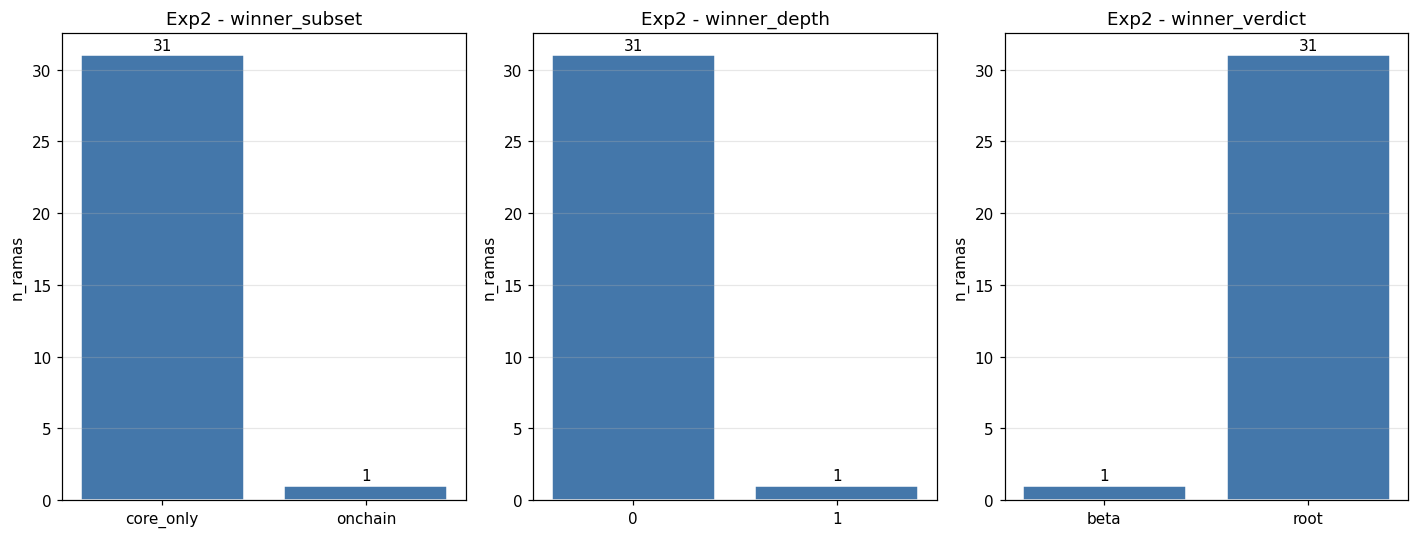

In [15]:
subset_counts = winners['winner_subset'].value_counts().sort_index()
depth_counts = winners['winner_depth'].astype('Int64').value_counts().sort_index()
verdict_counts = winners['winner_verdict'].value_counts().sort_index()
a_es(subset_counts.to_frame('n_ramas')).to_csv(FIG_DIR / 'exp2_winner_subset_counts.csv')
a_es(depth_counts.to_frame('n_ramas')).to_csv(FIG_DIR / 'exp2_winner_depth_counts.csv')
a_es(verdict_counts.to_frame('n_ramas')).to_csv(FIG_DIR / 'exp2_winner_verdict_counts.csv')

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, series, title in zip(
    axes,
    [subset_counts, depth_counts, verdict_counts],
    ['winner_subset', 'winner_depth', 'winner_verdict'],
):
    labels = [str(x) for x in series.index]
    values = series.values
    ax.bar(labels, values, color='#4477AA', edgecolor='white')
    ax.set_title(f'Exp2 - {title}')
    ax.set_ylabel('n_ramas')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(values):
        ax.text(i, v + 0.2, str(int(v)), ha='center', va='bottom', fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / 'exp2_greedy_decision_dimensions.png')
plt.show()

## 2.1 Veredictos sobre los nodos hijo evaluados (no solo del ganador)

La sección 2 resume la decisión final del greedy por rama (`winner_verdict` sobre 32 ramas). Esa lectura confunde "no se eligió" con "no se evaluó": el driver, antes de quedarse en `core_only`, evalúa un nodo hijo por cada bloque candidato (`derivatives_futures`, `microstructure`, `onchain`, `sentiment`, `attention`) y le asigna veredicto `alpha`/`beta`/`gamma` según el Wilcoxon pareado y el delta de Sharpe vs. el padre.

Esta subsección refleja esa capa: cuántas expansiones hijo se evaluaron, cuántas pasaron el umbral estadístico y cuál fue el reparto por fuente. Es evidencia **categórica** complementaria a la lectura **numérica** de la sección 4 (mediana de delta de Sharpe y p-Wilcoxon).

nodos_total=192  raiz=32  hijos_evaluados=160


,veredicto,n_nodos
0,alpha,159
1,root,32
2,beta,1


verdict,bloque_alternativo,alpha,beta,gamma,n_nodos,tasa_aceptacion_gamma
0,attention,32,0,0,32,0.0
1,derivatives_futures,32,0,0,32,0.0
2,microstructure,32,0,0,32,0.0
3,onchain,31,1,0,32,0.0
4,sentiment,32,0,0,32,0.0


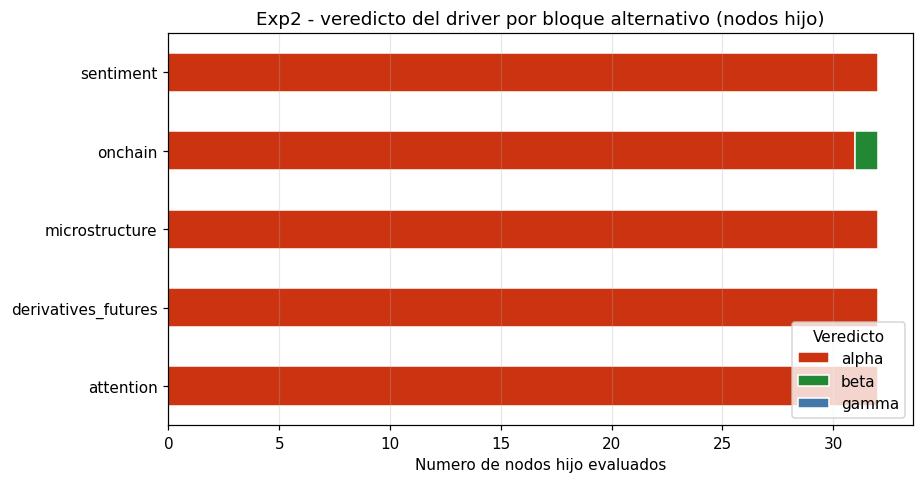

In [16]:
nodes_long = build_exp2_greedy_nodes_long(REPORT_ROOT, branch_stamp=BRANCH_STAMP)
verdict_counts_total = build_exp2_node_verdict_counts(nodes_long)
source_acceptance = build_exp2_source_acceptance(nodes_long)

n_root = int(verdict_counts_total.loc[verdict_counts_total['verdict'] == 'root', 'n_nodes'].sum())
n_child = int(verdict_counts_total.loc[verdict_counts_total['verdict'] != 'root', 'n_nodes'].sum())
print(f'nodos_total={n_root + n_child}  raiz={n_root}  hijos_evaluados={n_child}')

verdict_counts_total.to_csv(FIG_DIR / 'exp2_node_verdict_counts_total.csv', index=False)
source_acceptance.to_csv(FIG_DIR / 'exp2_source_acceptance.csv', index=False)

display_es(
    verdict_counts_total.rename(columns={'verdict': 'veredicto', 'n_nodes': 'n_nodos'})
)

source_acc_es = source_acceptance.rename(
    columns={
        'active_blocks_id': 'bloque_alternativo',
        'n_nodes': 'n_nodos',
        'acceptance_rate_gamma': 'tasa_aceptacion_gamma',
    }
)
display(source_acc_es)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
plot_df = source_acc_es.set_index('bloque_alternativo')[['alpha', 'beta', 'gamma']]
plot_df.plot.barh(stacked=True, ax=ax, color=['#CC3311', '#228833', '#4477AA'], edgecolor='white')
ax.set_xlabel('Numero de nodos hijo evaluados')
ax.set_ylabel('')
ax.set_title('Exp2 - veredicto del driver por bloque alternativo (nodos hijo)')
ax.legend(title='Veredicto', loc='lower right')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'exp2_source_acceptance_stacked.png')
plt.show()

## 3. Distribución del Sharpe agregado del nodo ganador

El `winner_aggregate_sharpe` mide el Sharpe agregado del fold de selección del greedy. Es la métrica
principal sobre la que el algoritmo decide aceptar o no la expansión del árbol.

,valor
n_ramas,32.000000
n_positivos,22.000000
n_negativos,10.000000
mediana,0.009951
media,0.012208
minimo,-0.026605
maximo,0.102087
desv_std,0.025239


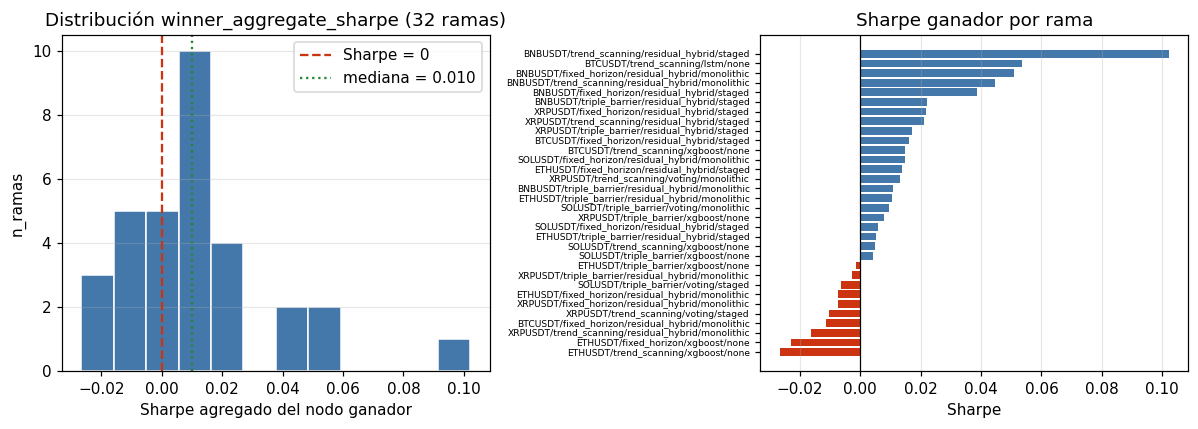

In [17]:
sharpe = winners['winner_aggregate_sharpe'].astype(float)
sharpe_stats = {
    'n_ramas': int(len(sharpe)),
    'n_positivos': int((sharpe > 0).sum()),
    'n_negativos': int((sharpe < 0).sum()),
    'mediana': float(sharpe.median()),
    'media': float(sharpe.mean()),
    'minimo': float(sharpe.min()),
    'maximo': float(sharpe.max()),
    'desv_std': float(sharpe.std(ddof=1)),
}
pd.DataFrame([sharpe_stats]).to_csv(FIG_DIR / 'exp2_sharpe_summary.csv', index=False)
display_es(pd.DataFrame([sharpe_stats]).T.rename(columns={0: 'valor'}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(sharpe.values, bins=12, color='#4477AA', edgecolor='white')
axes[0].axvline(0, color='#CC3311', linestyle='--', label='Sharpe = 0')
axes[0].axvline(sharpe.median(), color='#228833', linestyle=':', label=f'mediana = {sharpe.median():.3f}')
axes[0].set_title('Distribución winner_aggregate_sharpe (32 ramas)')
axes[0].set_xlabel('Sharpe agregado del nodo ganador')
axes[0].set_ylabel('n_ramas')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

by_family_sorted = winners.sort_values('winner_aggregate_sharpe', ascending=True)
colors = ['#CC3311' if v < 0 else '#4477AA' for v in by_family_sorted['winner_aggregate_sharpe']]
axes[1].barh(
    [f"{r['symbol']}/{r['method']}/{r['family']}/{r['injection_strategy']}"
     for _, r in by_family_sorted.iterrows()],
    by_family_sorted['winner_aggregate_sharpe'].values,
    color=colors,
)
axes[1].set_title('Sharpe ganador por rama')
axes[1].set_xlabel('Sharpe')
axes[1].tick_params(axis='y', labelsize=6)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'exp2_sharpe_distribution_and_per_branch.png')
plt.show()

## 3.1 Heatmap del Sharpe ganador por celda x familia/inyección

La sección 3 muestra la **distribución global** y el ranking 1D por rama. Esta vista 2D
cruza dos dimensiones experimentales: **celda de mercado** (`símbolo/método`) frente a
**configuración de modelo** (`familia/estrategia_inyeccion`). Cada casilla contiene el
`winner_aggregate_sharpe` de la rama correspondiente y permite localizar visualmente
patrones que el barplot 1D oculta (ej.: si una familia rinde mejor en determinados
símbolos, o si una estrategia de inyección domina en algunas celdas y no en otras).

Las casillas vacías corresponden a combinaciones no planificadas en la campaña (no son
fallos del greedy, simplemente no estaban en el plan de 32 ramas).

Sharpe agregado del ganador por celda x familia/inyección


familia                   lstm residual_hybrid               voting            \
estrategia_inyeccion      none      monolithic    staged monolithic    staged   
simbolo metodo                                                                  
BNBUSDT fixed_horizon      NaN        0.051039  0.038570        NaN       NaN   
        trend_scanning     NaN        0.044667  0.102087        NaN       NaN   
        triple_barrier     NaN        0.010720  0.022141        NaN       NaN   
BTCUSDT fixed_horizon      NaN       -0.011330  0.016005        NaN       NaN   
        trend_scanning  0.0535             NaN       NaN        NaN       NaN   
ETHUSDT fixed_horizon      NaN       -0.007368  0.013712        NaN       NaN   
        trend_scanning     NaN             NaN       NaN        NaN       NaN   
        triple_barrier     NaN        0.010397  0.005062        NaN       NaN   
SOLUSDT fixed_horizon      NaN        0.014722  0.005898        NaN       NaN   
        trend_scanning     NaN             NaN       NaN        NaN       NaN   
        triple_barrier     NaN             NaN       NaN   0.009506 -0.006277   
XRPUSDT fixed_horizon      NaN       -0.007400  0.021817        NaN       NaN   
        trend_scanning     NaN       -0.016431  0.020956   0.013319 -0.010504   
        triple_barrier     NaN       -0.002656  0.017244        NaN       NaN   

familia                  xgboost  
estrategia_inyeccion        none  
simbolo metodo                    
BNBUSDT fixed_horizon        NaN  
        trend_scanning       NaN  
        triple_barrier       NaN  
BTCUSDT fixed_horizon        NaN  
        trend_scanning  0.014756  
ETHUSDT fixed_horizon  -0.023002  
        trend_scanning -0.026605  
        triple_barrier -0.001347  
SOLUSDT fixed_horizon        NaN  
        trend_scanning  0.005055  
        triple_barrier  0.004384  
XRPUSDT fixed_horizon        NaN  
        trend_scanning       NaN  
        triple_barrier  0.008030

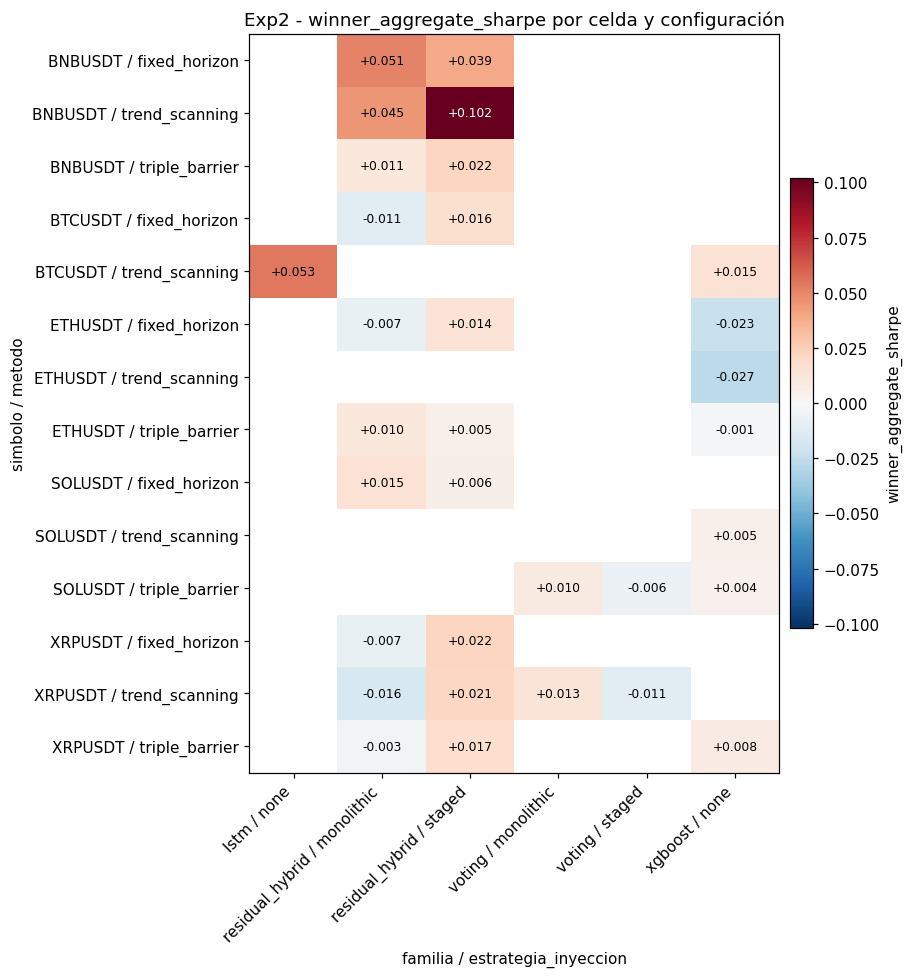

In [18]:
heat = winners.pivot_table(
    index=['symbol', 'method'],
    columns=['family', 'injection_strategy'],
    values='winner_aggregate_sharpe',
    aggfunc='first',
)
heat = heat.sort_index(axis=0).sort_index(axis=1)

heat_es = heat.copy()
heat_es.index = heat_es.index.set_names(['simbolo', 'metodo'])
heat_es.columns = heat_es.columns.set_names(['familia', 'estrategia_inyeccion'])
heat_es.to_csv(FIG_DIR / 'exp2_winner_sharpe_heatmap.csv')
print('Sharpe agregado del ganador por celda x familia/inyección')
display(heat_es)

values = heat.values.astype(float)
abs_max = float(np.nanmax(np.abs(values))) if values.size else 1.0
abs_max = abs_max if abs_max > 0 else 1.0
fig, ax = plt.subplots(figsize=(max(6, 0.9 * heat.shape[1] + 3), max(3.5, 0.5 * heat.shape[0] + 2)))
im = ax.imshow(values, cmap='RdBu_r', vmin=-abs_max, vmax=abs_max, aspect='auto')
ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels([' / '.join(map(str, col)) for col in heat.columns], rotation=45, ha='right')
ax.set_yticks(range(heat.shape[0]))
ax.set_yticklabels([' / '.join(map(str, idx)) for idx in heat.index])
ax.set_xlabel('familia / estrategia_inyeccion')
ax.set_ylabel('simbolo / metodo')
ax.set_title('Exp2 - winner_aggregate_sharpe por celda y configuración')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = values[i, j]
        if np.isnan(v):
            continue
        color = 'white' if abs(v) > 0.55 * abs_max else 'black'
        ax.text(j, i, f'{v:+.3f}', ha='center', va='center', color=color, fontsize=8)
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label('winner_aggregate_sharpe')
fig.tight_layout()
fig.savefig(FIG_DIR / 'exp2_winner_sharpe_heatmap.png')
plt.show()

## 4. Valor añadido por bloque de fuentes

`source_value_added_stats.csv` agrega, por bloque alternativo, la mediana del delta de Sharpe vs. nodo padre
y el p-valor del Wilcoxon de pares. Si la mejora fuera robusta **en toda la campaña**, esperaríamos delta > 0 y p < 0.05.

A nivel agregado (32 ramas), **ningún bloque supera ese umbral de forma sistemática** (`p_Wilcoxon` entre 0.57 y 0.66;
deltas medianos cercanos a cero). Eso no contradice aceptaciones **puntuales** del greedy en ramas concretas:
en la evidencia de nodos, solo **`onchain`** alcanza veredicto `beta` (1 nodo); **`sentiment`** puede mostrar deltas
positivos locales en ramas concretas, pero **no** obtiene `beta` ni `gamma` en ninguna rama (véase sección 2.1 y la tabla agregada de esta sección).

,bloque_alternativo,n_nodos,mediana_delta_sharpe,media_delta_sharpe,p_wilcoxon,mediana_sharpe_agregado
0,attention,32,0.000871,0.000434,0.663896,0.004740
1,sentiment,32,-0.000250,-0.000406,0.580376,0.006154
2,derivatives_futures,32,-0.000845,-0.000455,0.632315,0.008960
3,onchain,32,-0.001719,-0.002662,0.573155,0.003524
4,microstructure,32,-0.003516,-0.004402,0.575839,0.003839


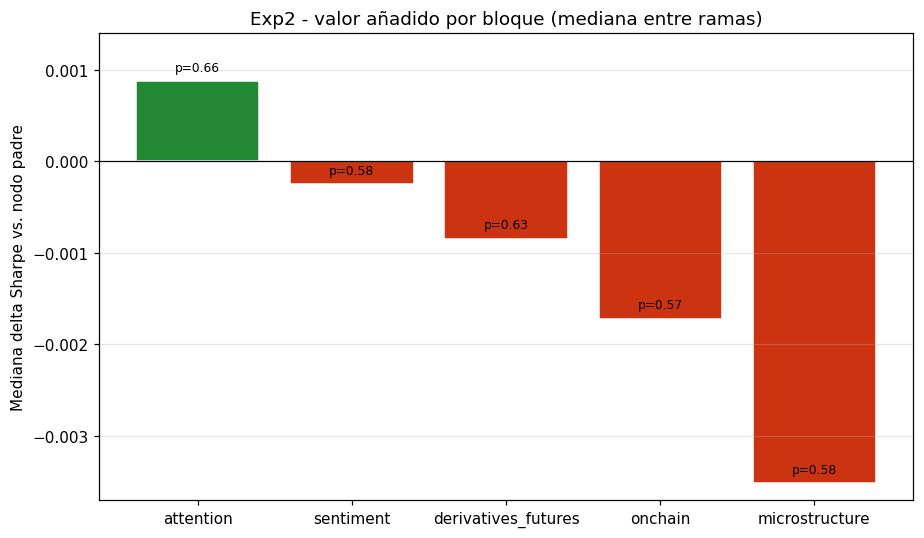

In [19]:
src_stats = load_exp2_source_value_added(REPORT_ROOT, branch_stamp=BRANCH_STAMP)
src_stats_es = a_es(src_stats)
src_stats_es.to_csv(FIG_DIR / 'exp2_source_value_added_stats.csv', index=False)
display_es(src_stats_es)

fig, ax = plt.subplots(figsize=(8.5, 5))
vals = src_stats_es['mediana_delta_sharpe'].astype(float)
ax.bar(
    src_stats_es['bloque_alternativo'],
    vals,
    color=['#228833' if v > 0 else '#CC3311' for v in vals],
    edgecolor='white',
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Mediana delta Sharpe vs. nodo padre')
ax.set_title('Exp2 - valor añadido por bloque (mediana entre ramas)')
ax.grid(axis='y', alpha=0.3)
y_span = max(vals.max(), 0) - min(vals.min(), 0)
label_pad = max(y_span * 0.12, 0.0004)
ax.set_ylim(min(vals.min(), 0) - label_pad * 0.35, max(vals.max(), 0) + label_pad)
for i, (val, pval) in enumerate(zip(vals, src_stats_es['p_wilcoxon'])):
    ax.text(
        i,
        val + label_pad * 0.15,
        f'p={pval:.2f}',
        ha='center',
        va='bottom',
        fontsize=8,
    )
fig.tight_layout()
fig.savefig(FIG_DIR / 'exp2_source_value_added.png')
plt.show()

## 5. Estrategia de inyección (staged vs. monolithic) - efecto sobre Sharpe

Para los pares (`symbol`, `method`, `family`) en los que existen ambas estrategias, comparamos el Sharpe ganador.
No hay dominancia clara de ninguna estrategia: la mediana del delta es prácticamente cero.

sharpe_por_etapas  sharpe_monolitico  \
simbolo metodo         familia                                                 
BNBUSDT fixed_horizon  residual_hybrid             0.0386             0.0510   
        trend_scanning residual_hybrid             0.1021             0.0447   
        triple_barrier residual_hybrid             0.0221             0.0107   
BTCUSDT fixed_horizon  residual_hybrid             0.0160            -0.0113   
ETHUSDT fixed_horizon  residual_hybrid             0.0137            -0.0074   
        triple_barrier residual_hybrid             0.0051             0.0104   
SOLUSDT fixed_horizon  residual_hybrid             0.0059             0.0147   
        triple_barrier voting                     -0.0063             0.0095   
XRPUSDT fixed_horizon  residual_hybrid             0.0218            -0.0074   
        trend_scanning residual_hybrid             0.0210            -0.0164   
                       voting                     -0.0105             0.0133   
        triple_barrier residual_hybrid             0.0172            -0.0027   

                                        diferencia_monolitico_menos_staged  
simbolo metodo         familia                                              
BNBUSDT fixed_horizon  residual_hybrid                              0.0125  
        trend_scanning residual_hybrid                             -0.0574  
        triple_barrier residual_hybrid                             -0.0114  
BTCUSDT fixed_horizon  residual_hybrid                             -0.0273  
ETHUSDT fixed_horizon  residual_hybrid                             -0.0211  
        triple_barrier residual_hybrid                              0.0053  
SOLUSDT fixed_horizon  residual_hybrid                              0.0088  
        triple_barrier voting                                       0.0158  
XRPUSDT fixed_horizon  residual_hybrid                             -0.0292  
        trend_scanning residual_hybrid                             -0.0374  
                       voting                                       0.0238  
        triple_barrier residual_hybrid                             -0.0199

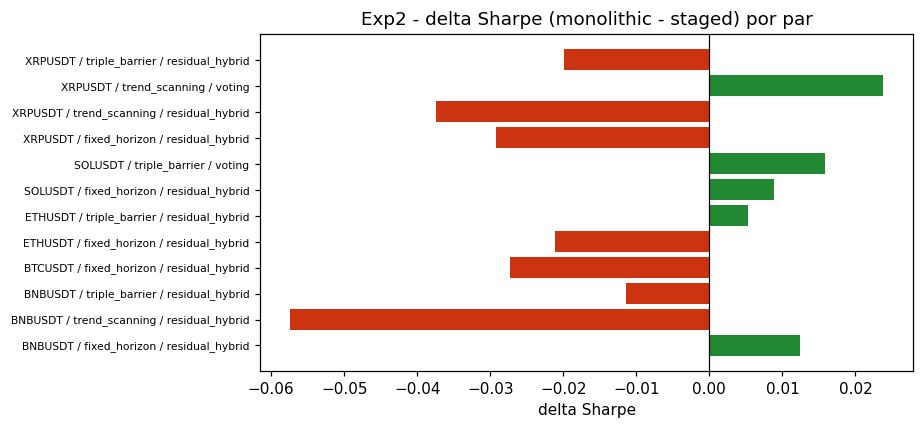

In [20]:
pivot = build_exp2_injection_staged_vs_monolithic_pivot(REPORT_ROOT, BRANCH_STAMP)
if not pivot.empty:
    pivot_es = a_es(pivot)
    pivot_es.to_csv(FIG_DIR / 'exp2_staged_vs_monolithic.csv')
    display_es(pivot_es.round(4))

    fig, ax = plt.subplots(figsize=(8.5, 4))
    labels = [' / '.join(map(str, idx)) for idx in pivot_es.index]
    diffs = pivot_es['diferencia_monolitico_menos_staged'].values
    ax.barh(labels, diffs, color=['#228833' if v > 0 else '#CC3311' for v in diffs])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Exp2 - delta Sharpe (monolithic - staged) por par')
    ax.set_xlabel('delta Sharpe')
    ax.tick_params(axis='y', labelsize=7)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'exp2_staged_vs_monolithic_delta.png')
    plt.show()
else:
    print('No hay pares staged/monolithic completos.')

## 6. Tiempos de ejecución y coste computacional

Resumen de la duración total de la campaña greedy (horas-CPU). Apoya la justificación de usar
**frozen replay + carril 2.5** posterior (`06_resumen_carril_riesgo_greedy_contextual.ipynb`), en lugar de reabrir Optuna por celda.

,valor
n_ramas,32.000000
mediana_horas,26.303543
media_horas,64.391764
minimo_horas,5.692607
maximo_horas,450.640101
suma_horas_cpu,2060.536440


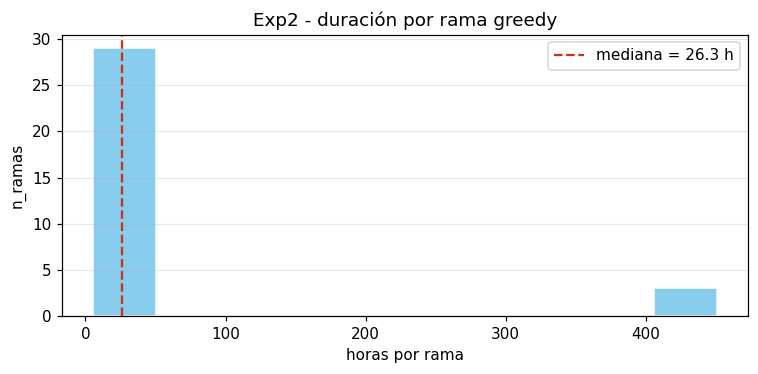

In [21]:
runtime = winners['branch_runtime_hours'].astype(float)
runtime_stats = {
    'n_ramas': int(len(runtime)),
    'mediana_horas': float(runtime.median()),
    'media_horas': float(runtime.mean()),
    'minimo_horas': float(runtime.min()),
    'maximo_horas': float(runtime.max()),
    'suma_horas_cpu': float(runtime.sum()),
}
pd.DataFrame([runtime_stats]).to_csv(FIG_DIR / 'exp2_runtime_summary.csv', index=False)
display_es(pd.DataFrame([runtime_stats]).T.rename(columns={0: 'valor'}))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(runtime.values, bins=10, color='#88CCEE', edgecolor='white')
ax.axvline(runtime.median(), color='#CC3311', linestyle='--', label=f'mediana = {runtime.median():.1f} h')
ax.set_xlabel('horas por rama')
ax.set_ylabel('n_ramas')
ax.set_title('Exp2 - duración por rama greedy')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'exp2_runtime_histogram.png')
plt.show()

## 7. DSR del campeón greedy (N acumulado Exp1 + Exp2)

**Pregunta:** ¿los campeones del Exp2 son estadísticamente defendibles una vez deflactados por todo lo probado en la celda `(simbolo, metodo)` durante Exp1 y Exp2?

En el Exp2 la **decisión greedy** se tomó por **Sharpe agregado OOS**. Este bloque añade el control de admisibilidad estadística del protocolo: **DSR >= 0.95**, deflactando por la multiplicidad acumulada en la celda:

$$
N = N_{\mathrm{exp1}} + N_{\mathrm{exp2}}
$$

- `N_exp1`: trials exploratorios + confirmatorios de la celda (típico 22).
- `N_exp2`: nodos evaluados por el greedy en esa celda (`greedy_tree.json`).
- `sr_std`: dispersión empírica de Sharpes intra-celda (Exp1 + Exp2).

**Insumos por rama:** estadísticos OOS del campeón (`nested_source_injection_summary.json`: Sharpe, `n_obs`, asimetría, curtosis) y los conteos celda anteriores. El DSR se calcula con `expected_max_sharpe` y `probabilistic_sharpe_ratio` (`src.validation.dsr`).


,simbolo,metodo,familia,subset_ganador,veredicto_ganador,sharpe_oos,n_trials_exp1,n_trials_exp2,n_trials_total,sharpe_max_esperado,dsr_exp2,dsr_supera_0_95
0,BNBUSDT,trend_scanning,residual_hybrid,core_only,root,0.102087,22,12,34,0.083363,9.964894e-01,True
1,BTCUSDT,trend_scanning,lstm,core_only,root,0.053500,22,12,34,0.040461,9.576047e-01,True
2,BNBUSDT,fixed_horizon,residual_hybrid,core_only,root,0.051039,22,12,34,0.049154,6.000652e-01,False
3,XRPUSDT,triple_barrier,residual_hybrid,core_only,root,0.017244,22,18,40,0.018476,4.379878e-01,False
4,XRPUSDT,triple_barrier,xgboost,core_only,root,0.008030,22,18,40,0.018476,9.307931e-02,False
5,BNBUSDT,triple_barrier,residual_hybrid,core_only,root,0.022141,22,12,34,0.032408,8.994360e-02,False
6,BNBUSDT,fixed_horizon,residual_hybrid,core_only,root,0.038570,22,12,34,0.049154,7.968045e-02,False
7,SOLUSDT,triple_barrier,voting,onchain,beta,0.009506,22,18,40,0.029121,1.994655e-02,False
8,ETHUSDT,triple_barrier,residual_hybrid,core_only,root,0.010397,22,18,40,0.028977,7.048309e-03,False
9,SOLUSDT,triple_barrier,xgboost,core_only,root,0.004384,22,18,40,0.029121,4.770732e-03,False


Ramas con DSR >= 0.95: 2 / 32
Mediana DSR: 0.0005 | Mediana Sharpe OOS: 0.0100 | Mediana E[max SR]: 0.0425


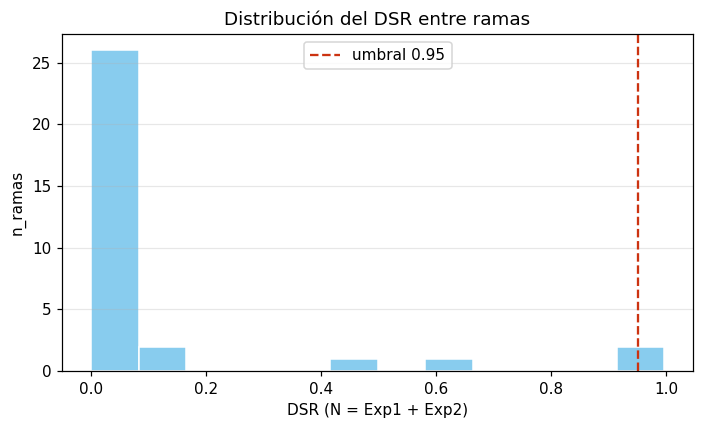

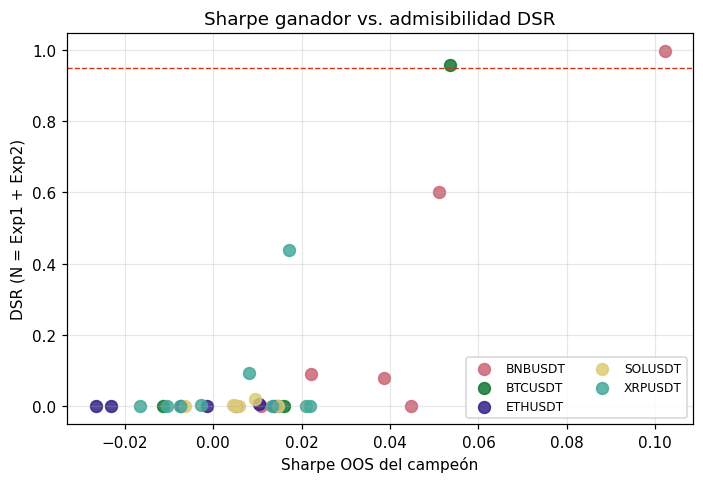

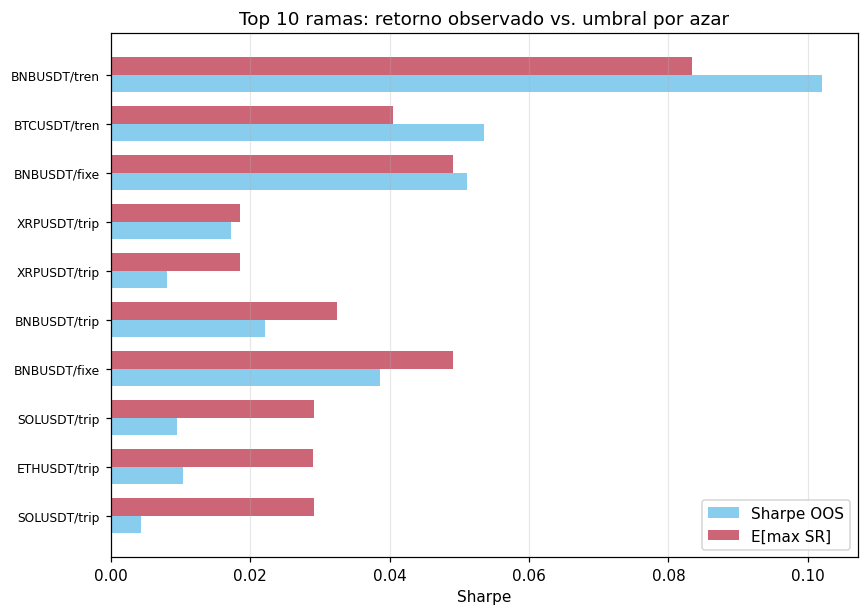

,simbolo,n_ramas,n_admisibles,mediana_dsr
0,BNBUSDT,6,1,8.481203e-02
1,BTCUSDT,4,1,5.276600e-04
3,SOLUSDT,6,0,3.552934e-04
2,ETHUSDT,7,0,3.076747e-05
4,XRPUSDT,9,0,5.401240e-09


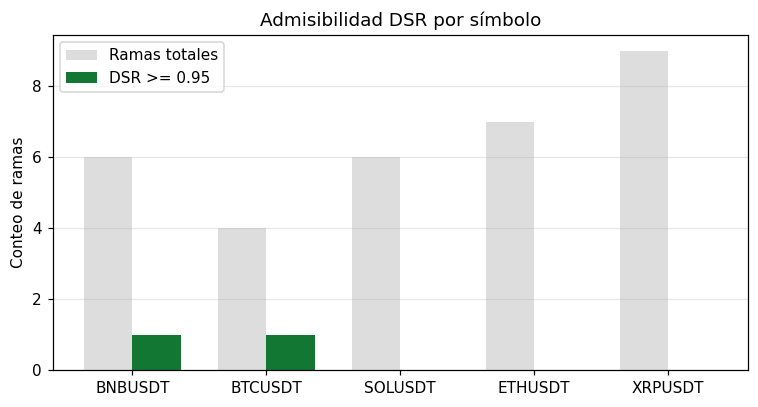

In [22]:
import json
import math

from src.validation.dsr import (
    SharpeStats,
    expected_max_sharpe,
    probabilistic_sharpe_ratio,
)

EXP1_STAMP = EXP1_STAMP_DEFAULT
DSR_UMBRAL = 0.95


def _safe_float(value) -> float | None:
    if value is None:
        return None
    try:
        result = float(value)
    except (TypeError, ValueError):
        return None
    return result if math.isfinite(result) else None


def _read_json(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as fh:
        return json.load(fh)


def _collect_exp1_cell_deflators(experiments_root: Path, stamp: str) -> dict[tuple[str, str], dict]:
    out: dict[tuple[str, str], dict] = {}
    suffix = f'_{stamp}'
    for sub in sorted(experiments_root.iterdir()):
        if not sub.is_dir():
            continue
        name = sub.name
        if not name.startswith('baseline_shortlist_') or not name.endswith(suffix):
            continue
        if '__ffd_' in name or name.endswith('_evidence'):
            continue
        summary_path = sub / 'budgeted_search_summary.json'
        if not summary_path.is_file():
            continue
        payload = _read_json(summary_path)
        prepared = payload.get('prepared_study') or {}
        search = payload.get('search_result') or {}
        symbol = (prepared.get('symbol') or '').upper()
        method = prepared.get('method') or prepared.get('labeling_method') or ''
        if not symbol or not method:
            body = name.removeprefix('baseline_shortlist_').removesuffix(suffix)
            for cand in ('triple_barrier', 'trend_scanning', 'fixed_horizon'):
                if body.endswith('_' + cand):
                    symbol = body[: -(len(cand) + 1)].upper()
                    method = cand
                    break
        if not symbol or not method:
            continue
        cell = out.setdefault((symbol, method), {'n_trials': 0, 'sharpes': []})
        for row in (search.get('ranking_rows') or []) + (search.get('confirmatory_ranking_rows') or []):
            cell['n_trials'] += 1
            sr = _safe_float(row.get('aggregate_strategy_sharpe'))
            if sr is not None:
                cell['sharpes'].append(sr)
    return out


def _collect_exp2_cell_deflators(experiments_root: Path, branch_stamp: str) -> dict[tuple[str, str], dict]:
    out: dict[tuple[str, str], dict] = {}
    root = experiments_root / 'contextual_greedy' / branch_stamp
    if not root.is_dir():
        return out
    for tree_path in sorted(root.rglob('greedy_tree.json')):
        rel = tree_path.relative_to(root)
        parts = rel.parts
        if len(parts) < 3:
            continue
        symbol = parts[0].upper()
        method = parts[1]
        cell = out.setdefault((symbol, method), {'n_nodes': 0, 'sharpes': []})
        try:
            payload = _read_json(tree_path)
        except (OSError, json.JSONDecodeError):
            continue
        selector = payload.get('selector') or {}
        nodes_field = (
            selector.get('nodes')
            or payload.get('nodes')
            or payload.get('evaluated_nodes')
            or []
        )
        if isinstance(nodes_field, dict):
            nodes_iter = list(nodes_field.values())
        elif isinstance(nodes_field, list):
            nodes_iter = nodes_field
        else:
            nodes_iter = []
        for node in nodes_iter:
            if not isinstance(node, dict):
                continue
            cell['n_nodes'] += 1
            outcome = node.get('outcome') or {}
            sr = (
                _safe_float(outcome.get('aggregate_sharpe'))
                or _safe_float(node.get('aggregate_sharpe'))
                or _safe_float(node.get('strategy_sharpe'))
            )
            if sr is not None:
                cell['sharpes'].append(sr)
    return out


def _cell_sr_std(sharpes: list[float]) -> float:
    if len(sharpes) >= 2:
        return max(float(np.std(sharpes, ddof=1)), 1e-6)
    if sharpes:
        return max(abs(sharpes[0]) * 0.1, 1e-6)
    return 1e-6


def _load_champion_entry(report_root: Path, study_id: str, winner_subset: str) -> dict | None:
    summary_path = report_root / study_id / 'nested_source_injection_summary.json'
    if not summary_path.is_file():
        return None
    payload = _read_json(summary_path)
    ranking = payload.get('global_ranking') or payload.get('top_5_global') or []
    for entry in ranking:
        if str(entry.get('source_subset_id') or '') == str(winner_subset):
            return entry
    return ranking[0] if ranking else None


def _compute_dsr_exp2(
    observed_sr: float,
    n_obs: int,
    skewness: float,
    excess_kurtosis: float,
    n_trials: int,
    sr_std: float,
) -> tuple[float, float, float]:
    stats = SharpeStats(
        observed_sr=float(observed_sr),
        n_obs=int(n_obs),
        skewness=float(skewness),
        excess_kurtosis=float(excess_kurtosis),
    )
    e_max = expected_max_sharpe(max(int(n_trials), 1), sr_std=float(sr_std))
    psr = probabilistic_sharpe_ratio(stats, benchmark_sr=0.0)
    dsr = probabilistic_sharpe_ratio(stats, benchmark_sr=e_max)
    return float(e_max), float(psr), float(dsr)


exp1_cells = _collect_exp1_cell_deflators(REPORT_ROOT, EXP1_STAMP)
exp2_cells = _collect_exp2_cell_deflators(REPORT_ROOT, BRANCH_STAMP)

rows: list[dict] = []
for _, winner in winners.iterrows():
    symbol = str(winner['symbol']).upper()
    method = str(winner['method'])
    subset = str(winner['winner_subset'])
    study_id = str(winner['winner_study_id'])
    cell_key = (symbol, method)

    e1 = exp1_cells.get(cell_key, {'n_trials': 0, 'sharpes': []})
    e2 = exp2_cells.get(cell_key, {'n_nodes': 0, 'sharpes': []})
    n_total = int(e1['n_trials']) + int(e2['n_nodes'])
    sr_std = _cell_sr_std(list(e1['sharpes']) + list(e2['sharpes']))

    champion = _load_champion_entry(REPORT_ROOT, study_id, subset)
    if champion is None:
        continue

    observed_sr = _safe_float(champion.get('observed_sr'))
    n_obs = champion.get('n_obs')
    skew = champion.get('skewness')
    kurt = champion.get('excess_kurtosis')

    if observed_sr is None or n_obs is None or int(n_obs) < 3:
        e_max = psr = dsr = np.nan
    else:
        e_max, psr, dsr = _compute_dsr_exp2(
            observed_sr,
            int(n_obs),
            0.0 if skew is None else float(skew),
            0.0 if kurt is None else float(kurt),
            n_total,
            sr_std,
        )

    rows.append({
        'symbol': symbol,
        'method': method,
        'family': winner['family'],
        'injection_strategy': winner.get('injection_strategy', 'none'),
        'winner_subset': subset,
        'winner_verdict': winner['winner_verdict'],
        'winner_aggregate_sharpe': float(winner['winner_aggregate_sharpe']),
        'observed_sr': observed_sr,
        'n_obs': n_obs,
        'n_trials_exp1': int(e1['n_trials']),
        'n_trials_exp2': int(e2['n_nodes']),
        'n_trials_total': n_total,
        'sr_std_intra_celda': sr_std,
        'expected_max_sr': e_max,
        'psr_exp2': psr,
        'dsr_exp2': dsr,
        'dsr_supera_umbral': bool(dsr >= DSR_UMBRAL) if pd.notna(dsr) else False,
    })

dsr_df = pd.DataFrame(rows)
if dsr_df.empty:
    print('No se pudieron cargar estadísticos OOS de campeones Exp2.')
else:
    dsr_df = dsr_df.sort_values('dsr_exp2', ascending=False, na_position='last').reset_index(drop=True)

    columnas_dsr_es = {
        'symbol': 'simbolo',
        'method': 'metodo',
        'family': 'familia',
        'injection_strategy': 'estrategia_inyeccion',
        'winner_subset': 'subset_ganador',
        'winner_verdict': 'veredicto_ganador',
        'observed_sr': 'sharpe_oos',
        'n_obs': 'n_obs',
        'n_trials_exp1': 'n_trials_exp1',
        'n_trials_exp2': 'n_trials_exp2',
        'n_trials_total': 'n_trials_total',
        'sr_std_intra_celda': 'sr_std_intra_celda',
        'expected_max_sr': 'sharpe_max_esperado',
        'psr_exp2': 'psr_exp2',
        'dsr_exp2': 'dsr_exp2',
        'dsr_supera_umbral': 'dsr_supera_0_95',
    }

    cols_show = [
        'symbol', 'method', 'family', 'winner_subset', 'winner_verdict',
        'observed_sr',
        'n_trials_exp1', 'n_trials_exp2', 'n_trials_total',
        'expected_max_sr', 'dsr_exp2', 'dsr_supera_umbral',
    ]
    vista = dsr_df[cols_show].rename(columns=columnas_dsr_es)
    vista.to_csv(FIG_DIR / 'exp2_dsr_champion_per_branch.csv', index=False)
    display(vista)

    n_ok = int((dsr_df['dsr_exp2'] >= DSR_UMBRAL).sum())
    print(f'Ramas con DSR >= {DSR_UMBRAL:.2f}: {n_ok} / {len(dsr_df)}')
    print(
        f'Mediana DSR: {float(dsr_df["dsr_exp2"].median()):.4f} '
        f'| Mediana Sharpe OOS: {float(dsr_df["observed_sr"].median()):.4f} '
        f'| Mediana E[max SR]: {float(dsr_df["expected_max_sr"].median()):.4f}'
    )

    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    ax.hist(dsr_df['dsr_exp2'].dropna(), bins=12, color='#88CCEE', edgecolor='white')
    ax.axvline(DSR_UMBRAL, color='#CC3311', linestyle='--', label=f'umbral {DSR_UMBRAL}')
    ax.set_xlabel('DSR (N = Exp1 + Exp2)')
    ax.set_ylabel('n_ramas')
    ax.set_title('Distribución del DSR entre ramas')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'exp2_dsr_histogram.png')
    plt.show()

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    palette = {'BTCUSDT': '#117733', 'ETHUSDT': '#332288', 'BNBUSDT': '#CC6677',
               'SOLUSDT': '#DDCC77', 'XRPUSDT': '#44AA99'}
    for sym, grp in dsr_df.groupby('symbol'):
        ax.scatter(
            grp['observed_sr'], grp['dsr_exp2'],
            label=sym, alpha=0.85, s=60, color=palette.get(sym, '#999999'),
        )
    ax.axhline(DSR_UMBRAL, color='#CC3311', linestyle='--', linewidth=0.9)
    ax.set_xlabel('Sharpe OOS del campeón')
    ax.set_ylabel('DSR (N = Exp1 + Exp2)')
    ax.set_title('Sharpe ganador vs. admisibilidad DSR')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'exp2_dsr_sharpe_vs_dsr_scatter.png')
    plt.show()

    top_n = min(10, len(dsr_df))
    top = dsr_df.nlargest(top_n, 'dsr_exp2').iloc[::-1]
    labels = [f"{r['symbol']}/{r['method'][:4]}" for _, r in top.iterrows()]
    y = np.arange(len(top))
    fig, ax = plt.subplots(figsize=(8.0, max(4.0, 0.42 * len(top) + 1.5)))
    ax.barh(y - 0.18, top['observed_sr'], height=0.36, color='#88CCEE', label='Sharpe OOS')
    ax.barh(y + 0.18, top['expected_max_sr'], height=0.36, color='#CC6677', label='E[max SR]')
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Sharpe')
    ax.set_title(f'Top {top_n} ramas: retorno observado vs. umbral por azar')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'exp2_dsr_observed_vs_benchmark_top.png')
    plt.show()

    por_simbolo = (
        dsr_df.groupby('symbol', as_index=False)
        .agg(
            n_ramas=('dsr_exp2', 'size'),
            n_admisibles=('dsr_supera_umbral', 'sum'),
            mediana_dsr=('dsr_exp2', 'median'),
        )
        .sort_values('mediana_dsr', ascending=False)
    )
    display_es(por_simbolo)
    por_simbolo.to_csv(FIG_DIR / 'exp2_dsr_summary_by_symbol.csv', index=False)

    fig, ax = plt.subplots(figsize=(7.0, 3.8))
    x = np.arange(len(por_simbolo))
    ax.bar(x - 0.18, por_simbolo['n_ramas'], width=0.36, color='#DDDDDD', label='Ramas totales')
    ax.bar(x + 0.18, por_simbolo['n_admisibles'], width=0.36, color='#117733', label=f'DSR >= {DSR_UMBRAL}')
    ax.set_xticks(x)
    ax.set_xticklabels(por_simbolo['symbol'])
    ax.set_ylabel('Conteo de ramas')
    ax.set_title('Admisibilidad DSR por símbolo')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'exp2_dsr_admissibility_by_symbol.png')
    plt.show()


## 8. Conclusiones

- Campaña **completa**: 32/32 ramas evaluadas, 0 saltadas. Coste agregado ~2,061 horas-CPU (suma por rama; ver sec. 6).
- Umbrales del driver (sec. 1.1): Wilcoxon `alpha=0.10`, delta Sharpe `beta=0.05`, `gamma=0.05`, `max_depth=3`, orden de fuentes fijo sobre `core_only`.
- **Decisión por rama:** el greedy se queda en **`core_only`** en 31/32 ramas (`winner_verdict = root`, `winner_depth = 0`). La única expansión aceptada es **`onchain`** en SOLUSDT / `triple_barrier` / `voting` / `monolithic` (veredicto `beta`).
- **Valor añadido de fuentes (sección 2.1 + 4):** en cada rama se evalúan bloques alternativos como nodos hijo de `core_only`; que el ganador sea `core_only` no implica que no se hayan entrenado ni contrastado. Sobre los 160 nodos hijo evaluados, el driver rechazó el **99.4 %** de expansiones (`159 alpha`, `1 beta`, `0 gamma`; `tasa_aceptacion_gamma = 0` en todas las fuentes). La lectura numérica es coherente: ningún bloque mejora de forma robusta el Sharpe agregado (medianas de delta cercanas a cero; `p_Wilcoxon` entre 0.57 y 0.66). Excepción puntual: `onchain` (veredicto `beta` arriba); `sentiment` puede mostrar deltas positivos locales sin veredicto `beta` ni `gamma`.
- El Sharpe ganador agregado por rama tiene mediana 0.010 (redondeo de 0.009951 en sec. 3) y rango [-0.027, +0.102]: hay valor positivo en 22/32 ramas, pero la magnitud es modesta.
- `staged` vs. `monolithic` no muestra dominancia sistemática.
- **Auditoría fold winner vs. root:** en 31/32 ramas el ganador es `core_only`, por lo que no existe delta `winner` vs. `root`; la única expansión aceptada se inspecciona en las secciones 2.1 y 4 (veredictos y deltas pareados vs. nodo padre). No se mantiene un notebook auxiliar de dispersión inter-fold winner-root: aportaría filas triviales (delta = 0) en casi todo el panel.

**Implicación metodológica:** el Exp2 confirma que, sobre este panel y con los umbrales actuales del greedy, **añadir fuentes no compensa de forma generalizada**.

**Artefactos persistidos** (todos bajo `reports/figures/exp_synthesis/exp2/`):

- `exp2_greedy_thresholds.csv`, `exp2_winners_raw.csv`
- `exp2_branches_by_family.csv`, `exp2_branches_by_method.csv`, `exp2_branches_by_symbol.csv`
- `exp2_winner_subset_counts.csv`, `exp2_winner_depth_counts.csv`, `exp2_winner_verdict_counts.csv`
- `exp2_greedy_decision_dimensions.png`
- `exp2_node_verdict_counts_total.csv`, `exp2_source_acceptance.csv`, `exp2_source_acceptance_stacked.png`
- `exp2_sharpe_summary.csv`, `exp2_sharpe_distribution_and_per_branch.png`
- `exp2_winner_sharpe_heatmap.csv`, `exp2_winner_sharpe_heatmap.png`
- `exp2_source_value_added_stats.csv`, `exp2_source_value_added.png`
- `exp2_staged_vs_monolithic.csv`, `exp2_staged_vs_monolithic_delta.png`
- `exp2_runtime_summary.csv`, `exp2_runtime_histogram.png`
- `exp2_dsr_champion_per_branch.csv`, `exp2_dsr_histogram.png`, `exp2_dsr_sharpe_vs_dsr_scatter.png`
- `exp2_dsr_observed_vs_benchmark_top.png`, `exp2_dsr_summary_by_symbol.csv`, `exp2_dsr_admissibility_by_symbol.png`

**Lectura DSR:** con N acumulado Exp1+Exp2, solo **2/32** ramas superan DSR >= 0.95 (mediana DSR 0.0005); el greedy eligió por Sharpe, no por este gate. La auditoría cuantifica cuántas ramas habrían sido admisibles estadísticamente antes de congelar candidatos para etapas posteriores.